# Part I - Ford GoBike System Data
## by Zubair Abubakar

## Introduction
This dataset includes information about individual rides made in a bike-sharing system covering the greater San Francisco Bay area. It includes details such as the duration of rides, start and end times, start and end stations, user type, and more. The goal of this analysis is to explore the dataset to understand user behavior, ride patterns, and factors that influence ride duration.

## Preliminary Wrangling

In [66]:
# import all packages and set plots to be embedded inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# suppress warnings from final output
import warnings
warnings.simplefilter("ignore")

In [67]:
df = pd.read_csv('201902-fordgobike-tripdata.csv')

# high-level overview of data shape and composition
print("Dataset Overview:")

print("\nShape of the dataset:")
print(df.shape)

print("\nSummary Statistics of the dataset:")
print(df.info())

print("\nFirst 10 rows of the dataset:")
print(df.head(10))

Dataset Overview:

Shape of the dataset:
(183412, 16)

Summary Statistics of the dataset:
<class 'pandas.DataFrame'>
RangeIndex: 183412 entries, 0 to 183411
Data columns (total 16 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   duration_sec             183412 non-null  int64  
 1   start_time               183412 non-null  str    
 2   end_time                 183412 non-null  str    
 3   start_station_id         183215 non-null  float64
 4   start_station_name       183215 non-null  str    
 5   start_station_latitude   183412 non-null  float64
 6   start_station_longitude  183412 non-null  float64
 7   end_station_id           183215 non-null  float64
 8   end_station_name         183215 non-null  str    
 9   end_station_latitude     183412 non-null  float64
 10  end_station_longitude    183412 non-null  float64
 11  bike_id                  183412 non-null  int64  
 12  user_type                183412 non

### What is the structure of your dataset?

> There are 183412 rows and 16 columns in the dataset. The columns include information about the bike rides such as duration, start and end times, start and end stations, user type, and more. The data types of the columns vary, with some being numerical (e.g., duration_sec) and others being categorical (e.g., user_type).

### What is/are the main feature(s) of interest in your dataset?

> The main feature of interest in this dataset is the duration of the bike rides, which is represented by the 'duration_sec' column. This feature is crucial for understanding user behavior and the efficiency of the bike-sharing system.

### What features in the dataset do you think will help support your investigation into your feature(s) of interest?

> Features such as start_time, end_time, start_station_id, end_station_id, user_type, and bike_id can help support the investigation into the duration of bike rides. These features provide context about when and where rides occur, the type of users, and the specific bikes used, which can all influence ride duration.

## Univariate Exploration

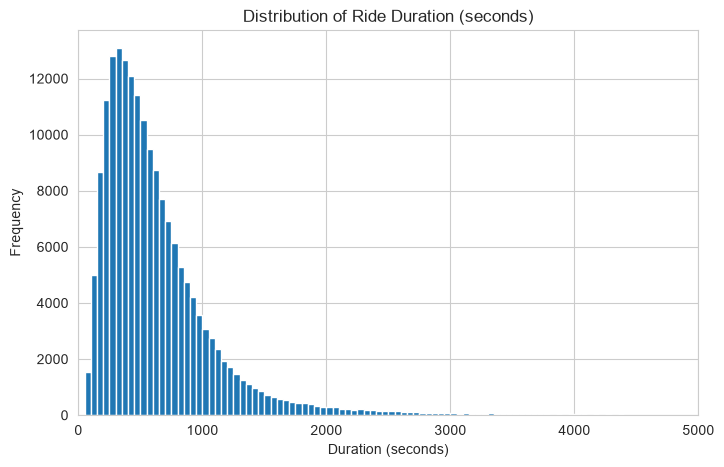

In [68]:
# standard-scaled plot for 'duration_sec'
binsize = 50
bins = np.arange(0, df['duration_sec'].max()+binsize, binsize)

plt.figure(figsize=[8, 5])
plt.hist(data=df, x='duration_sec', bins=bins)
plt.xlim(0, 5000)  # Limit x-axis to focus on the majority of the data
plt.xlabel('Duration (seconds)')
plt.ylabel('Frequency')
plt.title('Distribution of Ride Duration (seconds)')
plt.show()


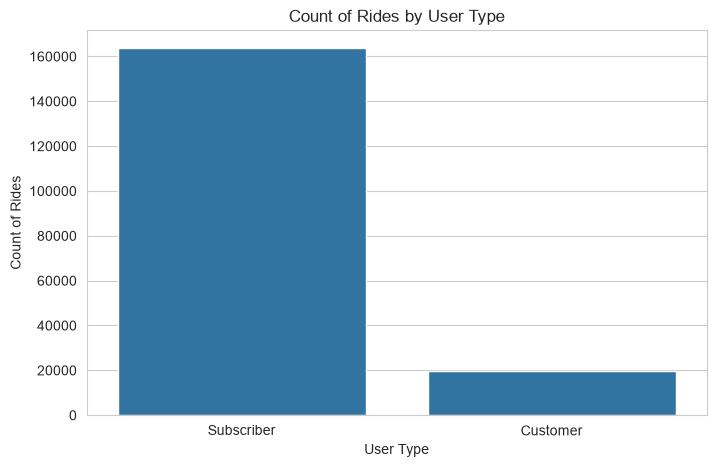

In [69]:
# countplot for user_type
plt.figure(figsize=[8, 5])
sns.countplot(data=df, x='user_type', order=df['user_type'].value_counts().index)
plt.title('Count of Rides by User Type')
plt.xlabel('User Type')
plt.ylabel('Count of Rides')
plt.show()

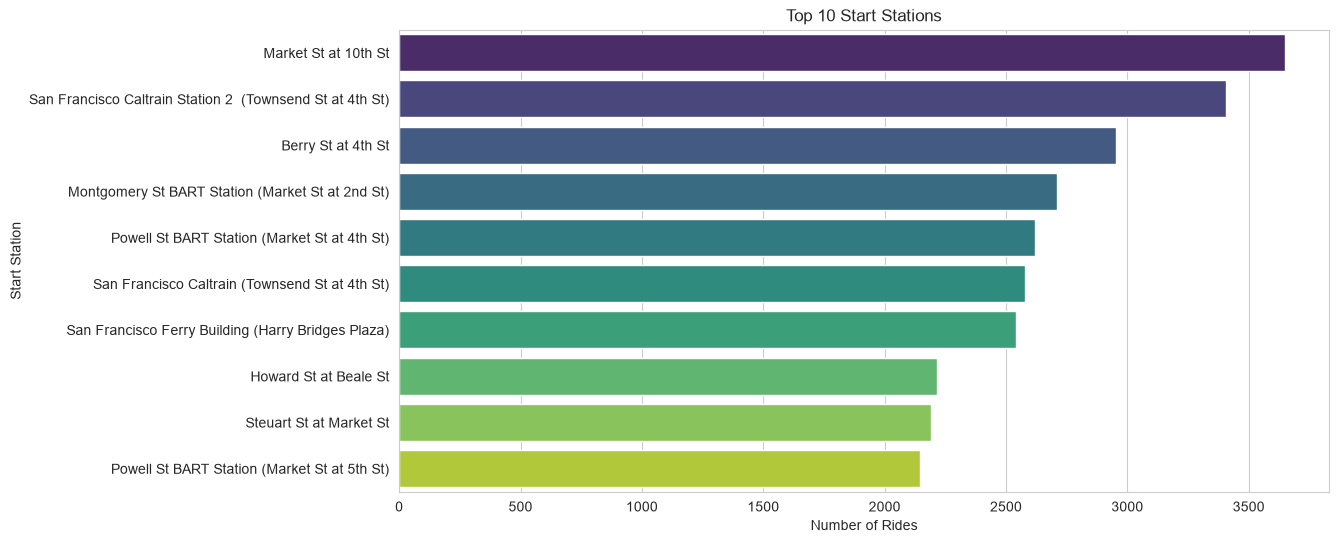

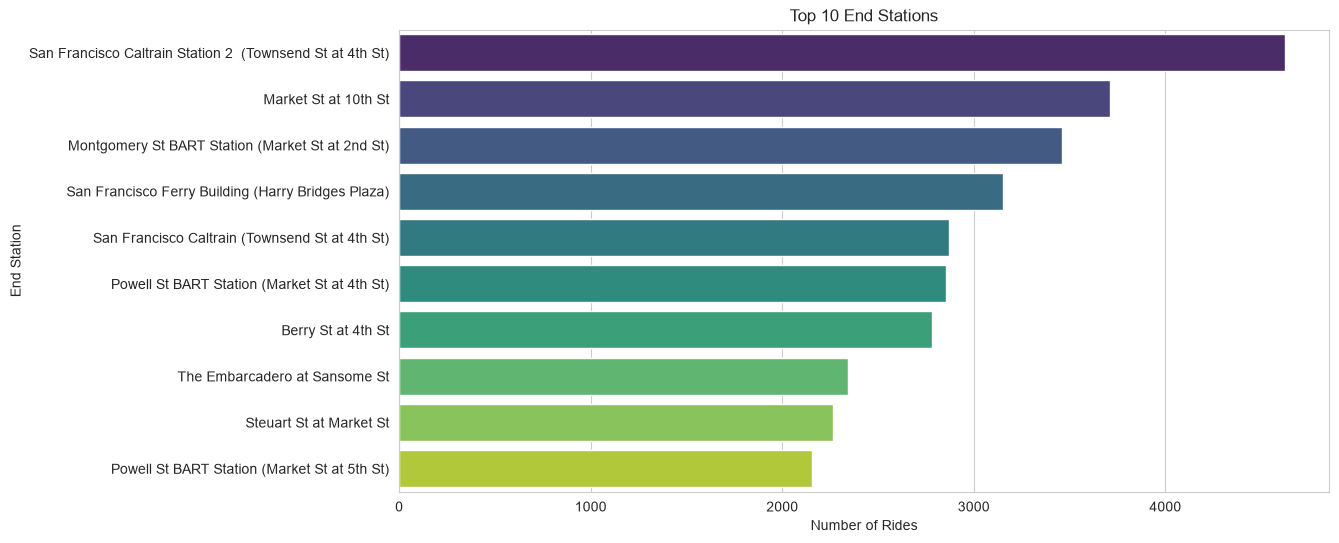

In [75]:
top_start_stations = df['start_station_name'].value_counts().head(10)
top_end_stations = df['end_station_name'].value_counts().head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x=top_start_stations.values, y=top_start_stations.index, palette='viridis')
plt.title('Top 10 Start Stations')
plt.xlabel('Number of Rides')
plt.ylabel('Start Station')
plt.show()

plt.figure(figsize=(12, 6))
sns.barplot(x=top_end_stations.values, y=top_end_stations.index, palette='viridis')
plt.title('Top 10 End Stations')
plt.xlabel('Number of Rides')
plt.ylabel('End Station')
plt.show()

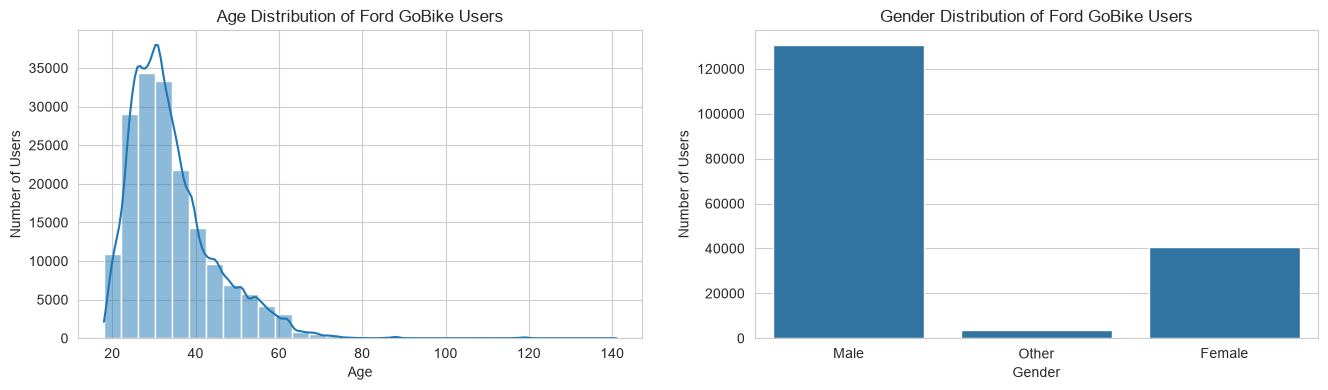

In [70]:
# Age and Gender distribution plots
df = df.dropna(subset=['member_birth_year', 'member_gender'])
df['age'] = 2019 - df['member_birth_year']
fig, axes = plt.subplots(1, 2, figsize=(16, 4))

sns.histplot(df['age'], bins=30, kde=True, ax=axes[0])
axes[0].set_title('Age Distribution of Ford GoBike Users')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Number of Users')

sns.countplot(x='member_gender', data=df, ax=axes[1])
axes[1].set_title('Gender Distribution of Ford GoBike Users')
axes[1].set_xlabel('Gender')
axes[1].set_ylabel('Number of Users')
plt.show()

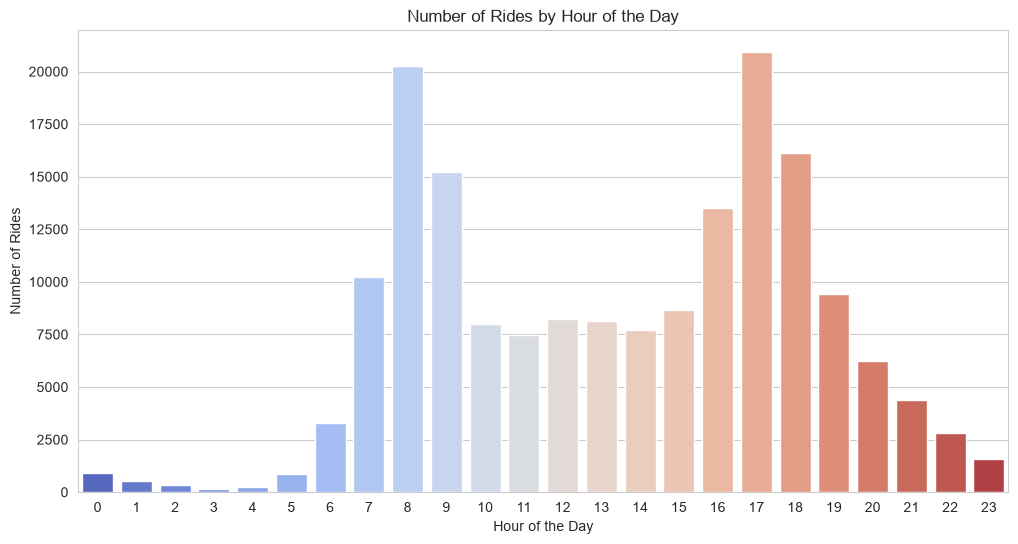

In [71]:
df['start_time'] = pd.to_datetime(df['start_time'])
df['hour_of_day'] = df['start_time'].dt.hour
plt.figure(figsize=(12, 6))

# FutureWarning:  Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.
sns.countplot(data=df, x='hour_of_day', palette='coolwarm')

plt.title('Number of Rides by Hour of the Day')
plt.xlabel('Hour of the Day')
plt.ylabel('Number of Rides')
plt.xticks(range(0, 24))
plt.show()

### Discuss the distribution(s) of your variable(s) of interest. Were there any unusual points? Did you need to perform any transformations?

> The distribution of the 'duration_sec' variable is right-skewed, with most rides having shorter durations and a few rides having very long durations. There are some unusual points or outliers with extremely high durations, which may represent data entry errors or atypical rides.
>
> The Number of Rides by Hour of the Day shows a clear pattern of ride frequency, with peaks during morning and evening commute hours. This indicates that the bike-sharing system is heavily used during these times, likely for commuting purposes.
>

### Of the features you investigated, were there any unusual distributions? Did you perform any operations on the data to tidy, adjust, or change the form of the data? If so, why did you do this?

> The 'duration_sec' feature had an unusual distribution due to the presence of outliers with very high values. To address this, I limited the x-axis in the histogram to focus on the majority of the data, which allowed for a clearer view of the distribution of ride durations. No other significant transformations were performed on the data at this stage.

## Bivariate Exploration

> In this section, investigate relationships between pairs of variables in your data. Make sure the variables that you cover here have been introduced in some fashion in the previous section (univariate exploration).



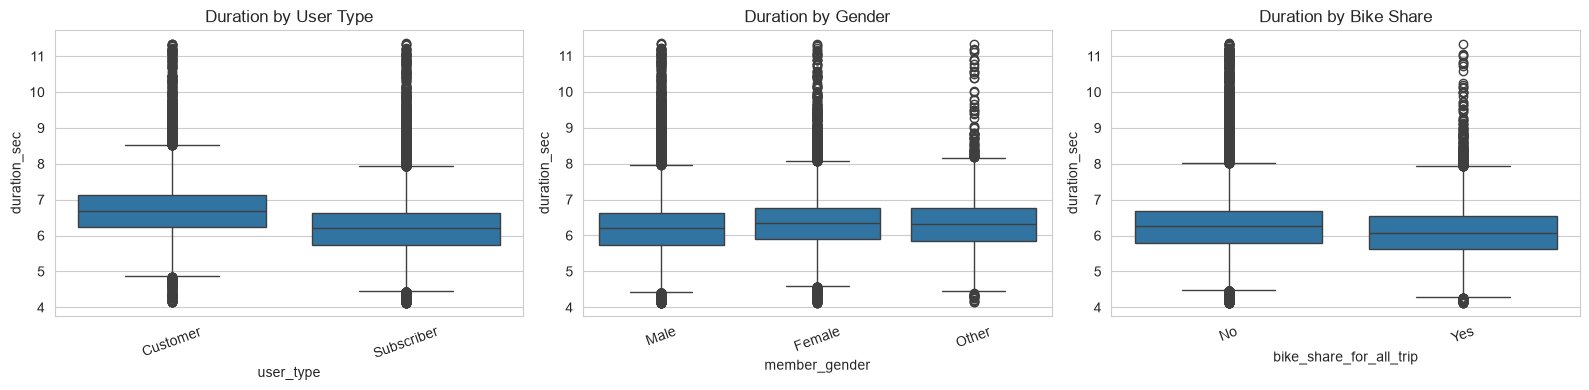

In [49]:
# needed columns
plot_df = df[['duration_sec', 'user_type', 'member_gender', 'bike_share_for_all_trip']].copy()
plot_df['duration_sec'] = pd.to_numeric(plot_df['duration_sec'], errors='coerce')
plot_df['duration_sec'] = np.log1p(plot_df['duration_sec'])
plot_df = plot_df.dropna(subset=['duration_sec'])
plot_df = plot_df[plot_df['duration_sec'] > 0]

# convert user_type, member_gender and bike_share_for_all_trip into ordered categorical types
cat_order = {
    'user_type': ['Customer', 'Subscriber'],
    'member_gender': ['Male', 'Female', 'Other'],
    'bike_share_for_all_trip': ['No', 'Yes']
}
for c, order in cat_order.items():
    present = [v for v in order if v in plot_df[c].dropna().unique()]
    plot_df[c] = pd.Categorical(plot_df[c], categories=present, ordered=True)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
sns.boxplot(data=plot_df, x='user_type', y='duration_sec', ax=axes[0])
axes[0].set_title('Duration by User Type')
axes[0].tick_params(axis='x', rotation=20)

sns.boxplot(data=plot_df, x='member_gender', y='duration_sec', ax=axes[1])
axes[1].set_title('Duration by Gender')
axes[1].tick_params(axis='x', rotation=20)

sns.boxplot(data=plot_df, x='bike_share_for_all_trip', y='duration_sec', ax=axes[2])
axes[2].set_title('Duration by Bike Share')
axes[2].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

# 2) Pairplot-compatible version: encode categoricals to numeric codes
pair_df = plot_df.copy()
pair_df['member_gender_code'] = pair_df['member_gender'].cat.codes
pair_df['bike_share_code'] = pair_df['bike_share_for_all_trip'].cat.codes
pair_df['user_type_code'] = pair_df['user_type'].cat.codes

# sample for speed/readability if needed
pair_sample = pair_df.sample(min(5000, len(pair_df)), random_state=42)



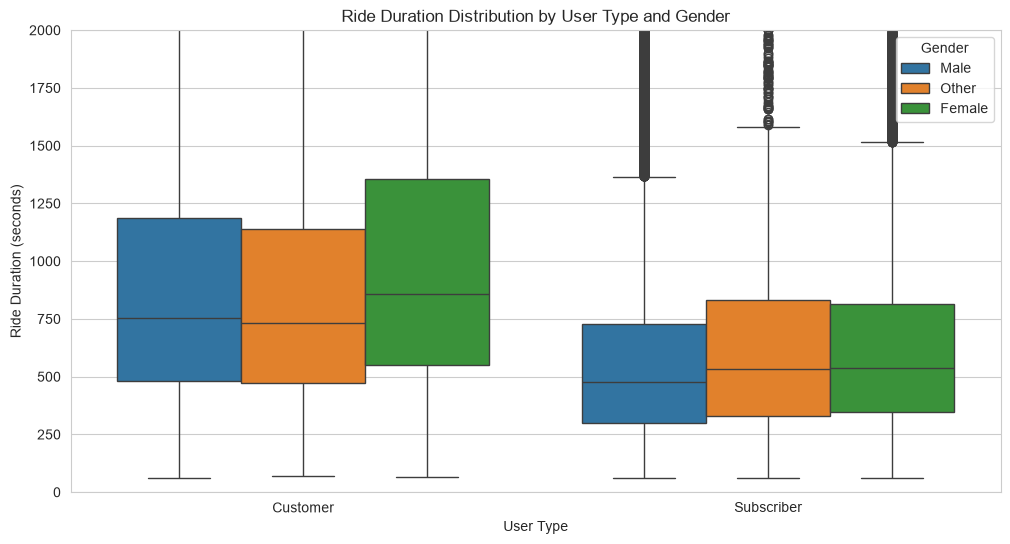

In [72]:
required_columns = ['duration_sec', 'user_type', 'member_gender']
df_filtered = df[required_columns].dropna()
plt.figure(figsize=(12, 6))
sns.boxplot(x='user_type', y='duration_sec', hue='member_gender', data=df_filtered)
plt.title('Ride Duration Distribution by User Type and Gender')
plt.xlabel('User Type')
plt.ylabel('Ride Duration (seconds)')
plt.ylim(0, 2000)  # Limit y-axis to focus on the majority of the data
plt.legend(title='Gender')
plt.show()

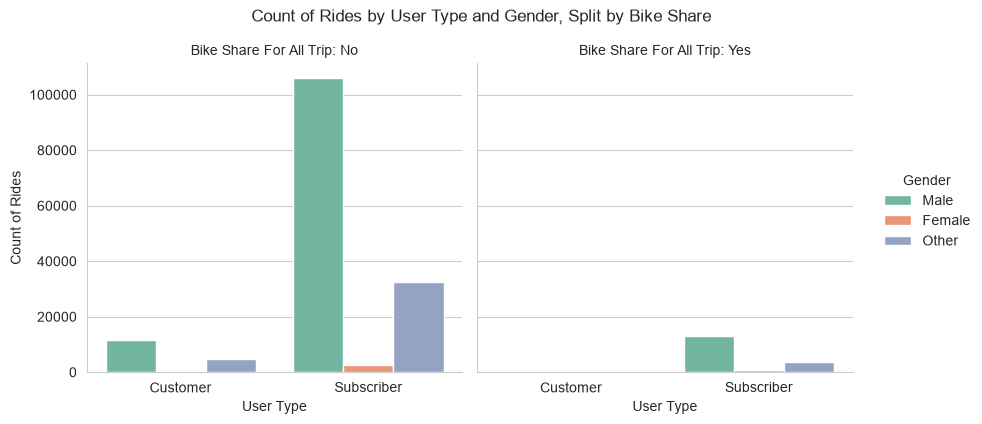

In [47]:
# a clustered countplot of user_type and member_gender, split by bike_share_for_all_trip
g = sns.catplot(
    data=plot_df,
    kind='count',
    x='user_type',
    hue='member_gender',
    col='bike_share_for_all_trip',   # split here
    palette='Set2',
    height=4,
    aspect=1.1
)

g.set_axis_labels('User Type', 'Count of Rides')
g.set_titles('Bike Share For All Trip: {col_name}')
g._legend.set_title('Gender')
g.fig.suptitle('Count of Rides by User Type and Gender, Split by Bike Share', y=1.05)
plt.show()

### Talk about some of the relationships you observed in this part of the investigation. How did the feature(s) of interest vary with other features in the dataset?

> The box plots show that ride duration varies significantly with user type, gender, and whether the ride was part of the bike share program. Subscribers tend to have shorter ride durations compared to customers. Additionally, there are differences in ride duration based on gender, with males generally having longer rides than females. The pair plot further illustrates these relationships, showing that the encoded categorical variables have distinct distributions in relation to ride duration.

### Did you observe any interesting relationships between the other features (not the main feature(s) of interest)?

> The pair plot reveals that there are interesting interactions between the categorical variables. For instance, the distribution of ride durations for different genders and bike share participation shows distinct patterns, suggesting that these factors may influence ride behavior. Additionally, the clustering of points in the pair plot indicates that user type has a strong effect on ride duration, with subscribers and customers exhibiting different ride patterns.

## Multivariate Exploration

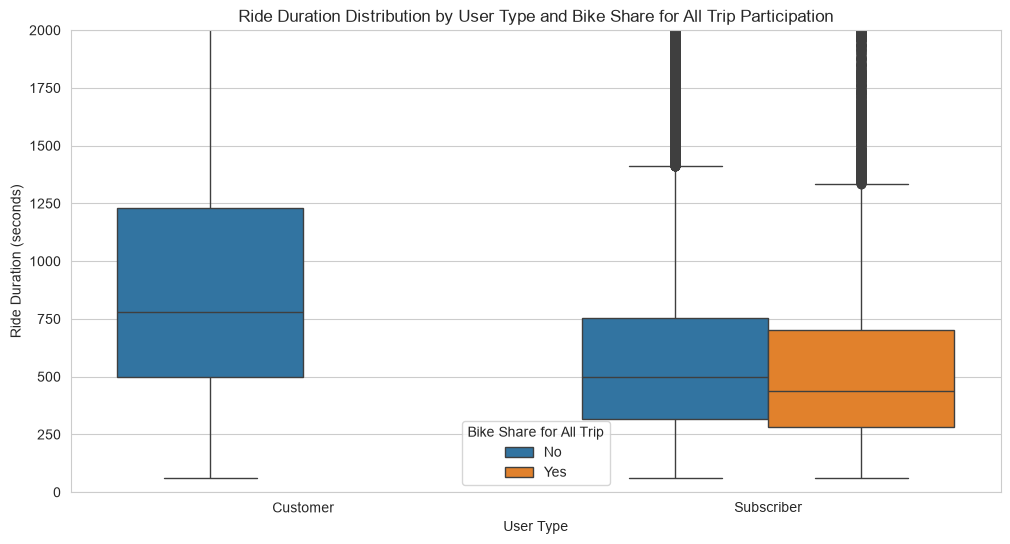

In [74]:
# Multivariate Exploration 1:
required_columns = ['duration_sec', 'user_type', 'bike_share_for_all_trip']
df_filtered = df[required_columns].dropna()
plt.figure(figsize=(12, 6))
sns.boxplot(x='user_type', y='duration_sec', hue='bike_share_for_all_trip', data=df_filtered)
plt.title('Ride Duration Distribution by User Type and Bike Share for All Trip Participation')
plt.xlabel('User Type')
plt.ylabel('Ride Duration (seconds)')
plt.ylim(0, 2000)  # Limit y-axis to focus on the majority of the data
plt.legend(title='Bike Share for All Trip')
plt.show()

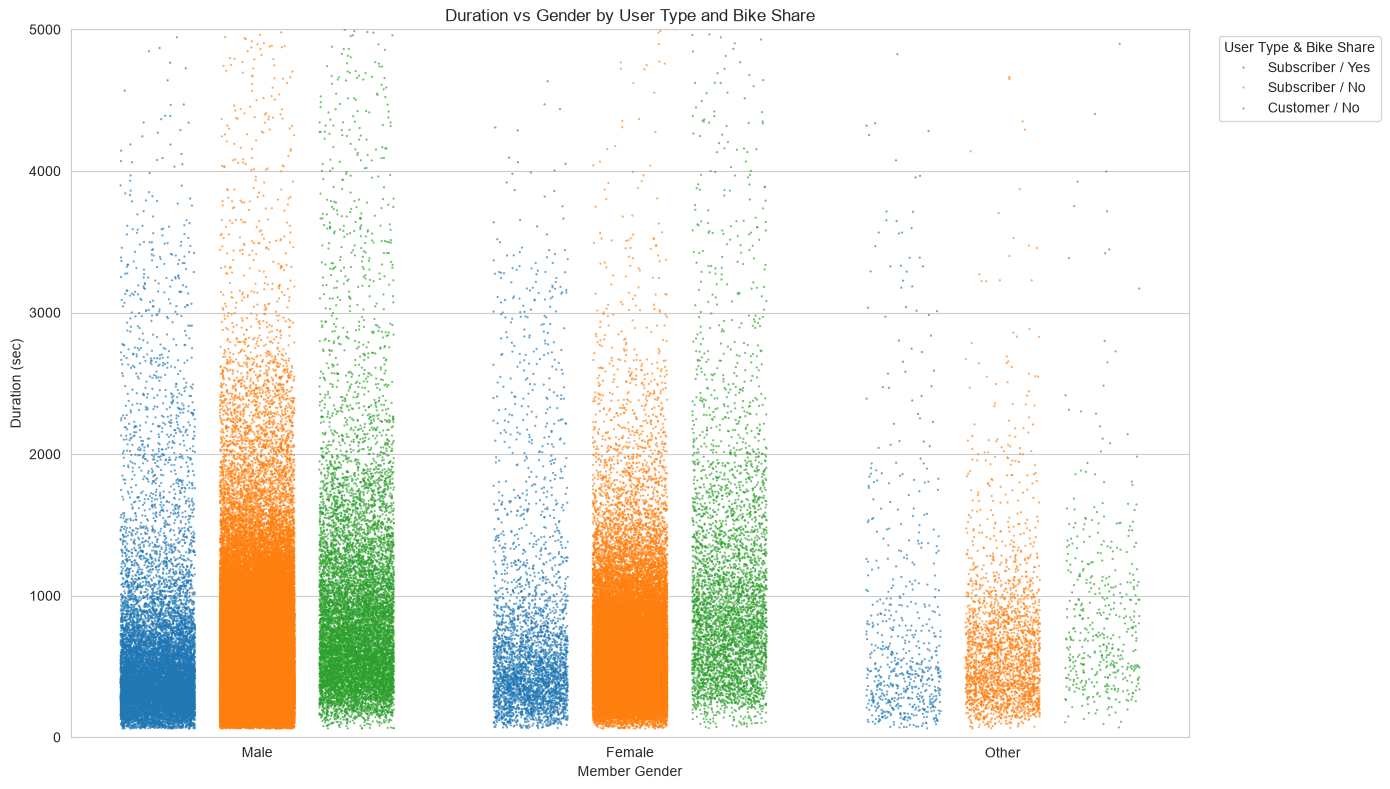

Median duration (sec) by user_type, gender, bike_share:


,user_type,member_gender,bike_share_for_all_trip,duration_sec
0,Customer,Female,No,836.0
1,Customer,Male,No,736.0
2,Customer,Other,No,720.0
3,Subscriber,Female,No,545.0
7,Subscriber,Other,No,540.0
5,Subscriber,Male,No,480.0
4,Subscriber,Female,Yes,478.0
8,Subscriber,Other,Yes,476.0
6,Subscriber,Male,Yes,425.0


In [73]:
# Multivariate Exploration 2:
# combine user_type and bike_share_for_all_trip into one hue variable for better visualization
multi_df = df.copy()
# clean + focused plotting frame
multi_df = df[['duration_sec', 'user_type', 'bike_share_for_all_trip', 'member_gender']].copy()

multi_df['duration_sec'] = pd.to_numeric(multi_df['duration_sec'], errors='coerce')
multi_df = multi_df.dropna(subset=['duration_sec', 'user_type', 'bike_share_for_all_trip', 'member_gender'])
multi_df = multi_df[(multi_df['duration_sec'] > 0) & (multi_df['duration_sec'] <= 5000)]

# combine user_type + bike_share_for_all_trip
multi_df['user_bike_share'] = (
    multi_df['user_type'].astype(str) + ' / ' + multi_df['bike_share_for_all_trip'].astype(str)
)

# optional fixed order for cleaner x-axis
gender_order = ['Male', 'Female', 'Other']
gender_order = [g for g in gender_order if g in multi_df['member_gender'].unique()]

plt.figure(figsize=(14, 8))
sns.stripplot(
    data=multi_df,
    x='member_gender',
    y='duration_sec',
    hue='user_bike_share',
    order=gender_order,
    dodge=True,
    jitter=0.3,
    alpha=0.65,
    size=1.6
)

plt.xlabel('Member Gender')
plt.ylabel('Duration (sec)')
plt.title('Duration vs Gender by User Type and Bike Share')
plt.ylim(0, 5000)
plt.legend(title='User Type & Bike Share', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Summary table to support visual findings
summary_tbl = (
    multi_df
    .groupby(['user_type', 'member_gender', 'bike_share_for_all_trip'])['duration_sec']
    .median()
    .reset_index()
    .sort_values('duration_sec', ascending=False)
)
print("Median duration (sec) by user_type, gender, bike_share:")
display(summary_tbl.head(12))

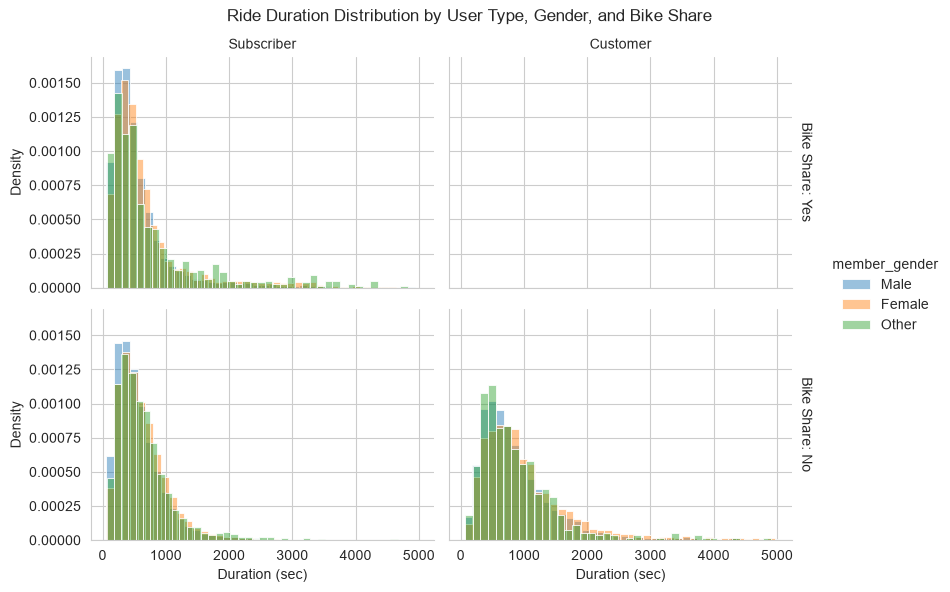

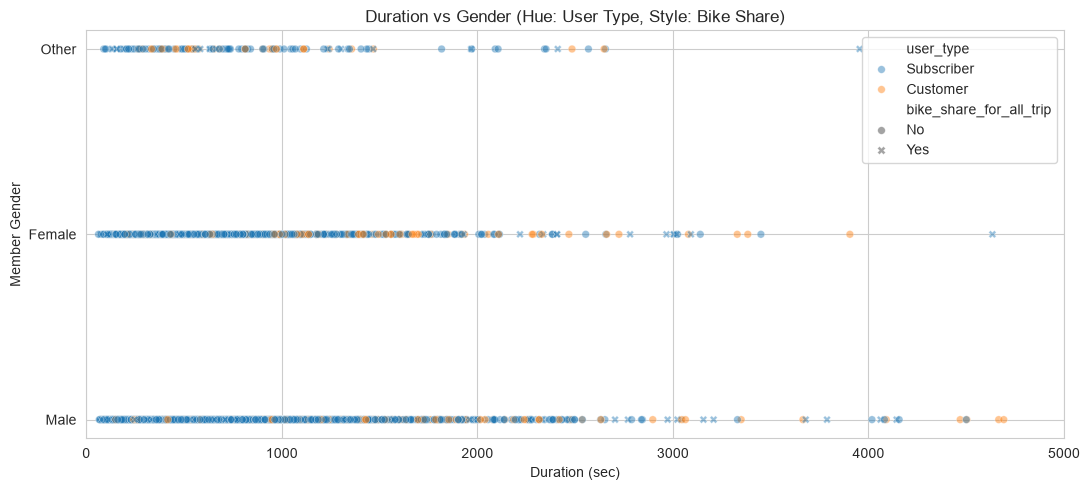

Median duration (sec) by user_type, gender, bike_share:


,user_type,member_gender,bike_share_for_all_trip,duration_sec
0,Customer,Female,No,836.0
1,Customer,Male,No,736.0
2,Customer,Other,No,720.0
3,Subscriber,Female,No,545.0
7,Subscriber,Other,No,540.0
5,Subscriber,Male,No,480.0
4,Subscriber,Female,Yes,478.0
8,Subscriber,Other,Yes,476.0
6,Subscriber,Male,Yes,425.0


In [32]:
# Multivariate Exploration 3
# I will use:
# - duration_sec (numeric target)
# - user_type, member_gender, bike_share_for_all_trip (categorical)
# This gives us 4 variables in combined views.

multi_df = df[['duration_sec', 'user_type', 'member_gender', 'bike_share_for_all_trip']].copy()
multi_df['duration_sec'] = pd.to_numeric(multi_df['duration_sec'], errors='coerce')
multi_df = multi_df.dropna(subset=['duration_sec', 'user_type', 'member_gender', 'bike_share_for_all_trip'])
multi_df = multi_df[(multi_df['duration_sec'] > 0) & (multi_df['duration_sec'] <= 5000)]

# 1) Facet Plot: duration distribution by user_type, split by bike_share_for_all_trip, colored by gender
g = sns.FacetGrid(
    data=multi_df,
    col='user_type',
    row='bike_share_for_all_trip',
    hue='member_gender',
    margin_titles=True,
    height=3,
    aspect=1.4
)
g.map(sns.histplot, 'duration_sec', bins=40, stat='density', common_norm=False, alpha=0.45)
g.add_legend()
g.set_axis_labels('Duration (sec)', 'Density')
g.set_titles(col_template='{col_name}', row_template='Bike Share: {row_name}')
g.fig.subplots_adjust(top=0.9)
g.fig.suptitle('Ride Duration Distribution by User Type, Gender, and Bike Share')
plt.show()


# 2) Scatterplot with multiple encodings:
#    x=duration, y=gender code, hue=user_type, style=bike_share_for_all_trip
scatter_df = multi_df.sample(min(6000, len(multi_df)), random_state=42).copy()
scatter_df['gender_code'] = scatter_df['member_gender'].map({'Male': 0, 'Female': 1, 'Other': 2})

plt.figure(figsize=(11, 5))
sns.scatterplot(
    data=scatter_df,
    x='duration_sec',
    y='gender_code',
    hue='user_type',
    style='bike_share_for_all_trip',
    alpha=0.45,
    s=30
)
plt.yticks([0, 1, 2], ['Male', 'Female', 'Other'])
plt.xlabel('Duration (sec)')
plt.ylabel('Member Gender')
plt.title('Duration vs Gender (Hue: User Type, Style: Bike Share)')
plt.xlim(0, 5000)
plt.tight_layout()
plt.show()

# 3) Summary table to support visual findings
summary_tbl = (
    multi_df
    .groupby(['user_type', 'member_gender', 'bike_share_for_all_trip'])['duration_sec']
    .median()
    .reset_index()
    .sort_values('duration_sec', ascending=False)
)
print("Median duration (sec) by user_type, gender, bike_share:")
display(summary_tbl.head(12))

# Pairplot with encoded categorical variables
g = sns.pairplot(
    pair_sample,
    vars=['duration_sec', 'member_gender_code', 'bike_share_code'],
    hue='user_type',
    diag_kind='hist',   # avoids KDE categorical issue
    height=2.8
)
g.fig.suptitle('Pair Plot (with encoded categorical vars)', y=1.02)
plt.show()

### Talk about some of the relationships you observed in this part of the investigation. Were there features that strengthened each other in terms of looking at your feature(s) of interest?

> The multivariate exploration revealed that the combination of user type, gender, and bike share participation provides a more nuanced understanding of ride duration. For example, subscribers who are male and participate in the bike share program tend to have shorter ride durations compared to customers who are female and do not participate in the bike share program. The facet plot clearly shows how these three categorical variables interact to influence ride duration, while the scatterplot highlights the distribution of durations across different genders and user types.

### Were there any interesting or surprising interactions between features?

> One surprising interaction observed was that the median ride duration for female subscribers participating in the bike share program was significantly lower than that of male customers not participating in the program. This suggests that the combination of gender, user type, and bike share participation can have a substantial impact on ride behavior. Additionally, the scatterplot indicated that there are distinct clusters of ride durations based on these categorical variables, which may warrant further investigation into the underlying factors driving these patterns.

## Conclusions:
> Here are the key insights from my analysis of the Ford GoBike System Data:
> 1. **Ride Duration Distribution**: The distribution of ride durations is right-skewed, with most rides being relatively short and a few outliers with very long durations. This suggests that while most users take short trips, there are occasional long rides that may be due to data entry errors or atypical user behavior.
> 2. **User Type Differences**: Subscribers tend to have shorter ride durations compared to customers. This indicates that subscribers may be more familiar with the system and use it for shorter, more efficient trips.
> 3. **Gender Differences**: There are notable differences in ride duration based on gender, with males generally having longer rides than females. This could be influenced by various factors, including trip purpose or physical ability.
> 4. **Bike Share Participation**: Users participating in the bike share program tend to have shorter ride durations compared to those who do not. This suggests that the bike share program may encourage more efficient use of the bikes, possibly due to time constraints or program incentives.
> 5. **Multivariate Interactions**: The combination of user type, gender, and bike share participation provides a more comprehensive understanding of ride duration. For instance, male subscribers participating in the bike share program tend to have the shortest ride durations, while female customers not participating in the program tend to have the longest. This highlights the importance of considering multiple factors when analyzing user behavior in bike-sharing systems.

